# Pip install
This section can be neglected thus the execution of this particular item is not required

In [ ]:
!pip install matplotlib

In [ ]:
!pip install datasets

# **1. Imports**
This section should be executed before any other cells.

In [142]:
### --- Start --- Common imports
from datasets import load_dataset as lod
import pandas as pd
from matplotlib import pyplot as PLT
import random as rmd
from PIL import Image
import os
import re
### --- End --- Common imports

### --- Start --- ML related imports
from torchvision.datasets import Cityscapes
from torch.utils.data import DataLoader
from torchvision.transforms.v2 import (
    Compose,
    Normalize,
    Resize,
    ToImage,
    ToDtype,
    InterpolationMode)
import torch
from huggingface_hub import hf_hub_download
from huggingface_hub import list_repo_files
### --- Start --- ML related imports

### --- Hard coded variables - Starts
path:str = r'/content/drive/MyDrive/Colab Notebooks/CityScape'
repo_id = 'TimJaspersTue/5LSM0'
repo_type = 'dataset'

country_map = {
    'stuttgart': 'Germany', 'hanover': 'Germany', 'aachen': 'Germany',
    'cologne': 'Germany', 'tubingen': 'Germany', 'weimar': 'Germany',
    'jena': 'Germany', 'erfurt': 'Germany', 'krefeld': 'Germany',
    'bochum': 'Germany', 'ulm': 'Germany', 'monchengladbach': 'Germany',
    'darmstadt': 'Germany', 'bremen': 'Germany', 'hamburg': 'Germany',
    'dusseldorf': 'Germany', 'strasbourg': 'France', 'zurich': 'Switzerland'
}
### --- Hard coded variables - Ends

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
dataset_path = '/content/drive/MyDrive/Colab Notebooks/CityScape' # Adjust this path if your dataset is located elsewhere

if os.path.exists(dataset_path):
    print(f"Contents of '{dataset_path}':")
    for item in os.listdir(dataset_path):
        print(item)
else:
    print(f"Dataset path '{dataset_path}' does not exist. Please check the path and ensure your Cityscapes dataset is uploaded/mounted correctly.")

Contents of '/content/drive/MyDrive/Colab Notebooks/CityScape':


# **2.Utilities and sanity checks**

### 2.1 **Authenticate with Hugging Face Hub for faster downloads**
This section is no longer used or required to be executed since the `lod` function neglects the directory that holds the raw images. The scraping is mostly executed manually (e.g., looping and saving the images paths)

To enable higher rate limits and faster downloads from Hugging Face Hub, one should authenticate using an `HF_TOKEN`.

In [97]:
# from huggingface_hub import login
# from google.colab import userdata

# # 1. Get the HF_TOKEN from Colab secrets
# hf_token = userdata.get('HuggingFaceAPI')

# # 2. Log in to Hugging Face Hub
# if hf_token:
#     login(token=hf_token)
#     print("Successfully logged in to Hugging Face Hub.")
# else:
#     print("HF_TOKEN not found in Colab secrets. Please add it to enable faster downloads.")

Successfully logged in to Hugging Face Hub.


In [89]:
# from datasets import load_dataset as lod
# dataset = lod('TimJaspersTue/5LSM0')
# print("Dataset loaded successfully!")

Resolving data files:   0%|          | 0/12360 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2515 [00:00<?, ?it/s]

Dataset loaded successfully!


### 2.2 **Verifying whether scraping manually and directly from repository works**

In [10]:
# 1. Download the raw image
image_path = hf_hub_download(
    repo_id=repo_id, # known
    repo_type=repo_type, # not known
    filename='cityscapes/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png'
)

# 2. Download the corresponding segmentation mask
mask_path = hf_hub_download(
    repo_id=repo_id,
    repo_type=repo_type,
    filename='cityscapes/gtFine/train/aachen/aachen_000000_000019_gtFine_labelIds.png'
)

print(f"Raw image downloaded to: {image_path}")
print(f"Segmentation mask downloaded to: {mask_path}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


cityscapes/leftImg8bit/train/aachen/aach(…):   0%|          | 0.00/2.13M [00:00<?, ?B/s]

cityscapes/gtFine/train/aachen/aachen_00(…):   0%|          | 0.00/19.7k [00:00<?, ?B/s]

Raw image downloaded to: /root/.cache/huggingface/hub/datasets--TimJaspersTue--5LSM0/snapshots/6af8e499236fb8cd2e564c168cd7b6715d82140a/cityscapes/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png
Segmentation mask downloaded to: /root/.cache/huggingface/hub/datasets--TimJaspersTue--5LSM0/snapshots/6af8e499236fb8cd2e564c168cd7b6715d82140a/cityscapes/gtFine/train/aachen/aachen_000000_000019_gtFine_labelIds.png


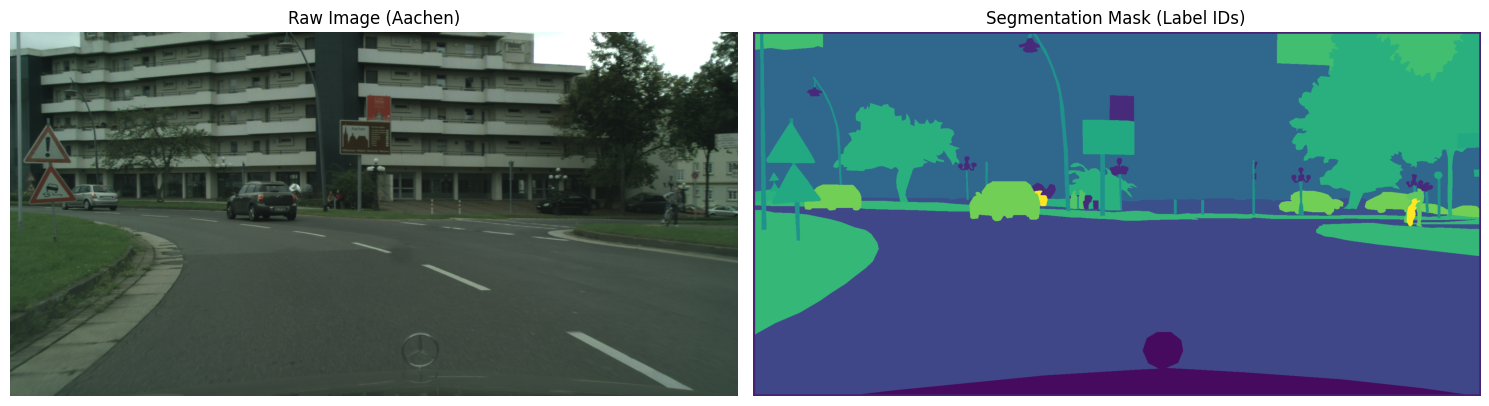

In [12]:
# 3. Load the downloaded images
raw_img = Image.open(image_path)
mask_img = Image.open(mask_path)

# Create a side-by-side visualization
fig, axes = PLT.subplots(1, 2, figsize=(15, 7))

# Display Raw Image
axes[0].imshow(raw_img)
axes[0].set_title("Raw Image (Aachen)")
axes[0].axis('off')

# Display Segmentation Mask
axes[1].imshow(mask_img)
axes[1].set_title("Segmentation Mask (Label IDs)")
axes[1].axis('off')

PLT.tight_layout()
PLT.show()

# **3. Exploratory Data Analysis**

## 3.1 Craft the data container `all_files` that hold both, raw images and their corresponding segmentation masks

In [20]:

# 1. Fetch all data paths from the targeted repository `repo_id`
all_files = list_repo_files(repo_id=repo_id, repo_type=repo_type)

# Debug Statement 1
# printing out summary statitics (e.g., the total number of paths which were
# retrieved succesfully and some examples)
print("No. of collections:{}\nExamples:{}".format(len(all_files),all_files[:10]))

No. of collections:14876
Examples:['.gitattributes', 'cityscapes/gtFine/train/aachen/aachen_000000_000019_gtFine_color.png', 'cityscapes/gtFine/train/aachen/aachen_000000_000019_gtFine_instanceIds.png', 'cityscapes/gtFine/train/aachen/aachen_000000_000019_gtFine_labelIds.png', 'cityscapes/gtFine/train/aachen/aachen_000000_000019_gtFine_polygons.json', 'cityscapes/gtFine/train/aachen/aachen_000001_000019_gtFine_color.png', 'cityscapes/gtFine/train/aachen/aachen_000001_000019_gtFine_instanceIds.png', 'cityscapes/gtFine/train/aachen/aachen_000001_000019_gtFine_labelIds.png', 'cityscapes/gtFine/train/aachen/aachen_000001_000019_gtFine_polygons.json', 'cityscapes/gtFine/train/aachen/aachen_000002_000019_gtFine_color.png']


## 3.2 Parse and pair data files (e.g., mask and its correspondent raw image)

In [37]:
# 2. Initialize collections
raw_images = {}
masks = {}

# 3. & 4. Iterate and extract sample IDs
# Pattern for raw images: .../leftImg8bit/split/city/sampleID_leftImg8bit.png
# Pattern for masks: .../gtFine/split/city/sampleID_gtFine_labelIds.png

for path in all_files:
    if 'leftImg8bit.png' in path:
        # Example: cityscapes/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png
        parts = path.split('/')
        split = parts[2]
        city = parts[3]
        filename = parts[-1]
        sample_id = filename.replace('_leftImg8bit.png', '')
        raw_images[sample_id] = {'path': path, 'split': split, 'city': city}

    elif '_gtFine_labelIds.png' in path:
        # Example: cityscapes/gtFine/train/aachen/aachen_000000_000019_gtFine_labelIds.png
        parts = path.split('/')
        filename = parts[-1]
        sample_id = filename.replace('_gtFine_labelIds.png', '')
        masks[sample_id] = path

# 5. Create mapping of matched pairs
matched_data = []
for sample_id, info in raw_images.items():
    if sample_id in masks:
        matched_data.append({
            'sample_id': sample_id,
            'split': info['split'],
            'city': info['city'],
            'raw_image_path': info['path'],
            'mask_path': masks[sample_id]
        })

# 6. Print results
print(f"Total raw images found: {len(raw_images)}")
print(f"Total masks found: {len(masks)}")
print(f"Total matched pairs: {len(matched_data)}")

# Show a sample to verify
if matched_data:
    print("\nSample entry:")
    print(matched_data[0])

Total raw images found: 2975
Total masks found: 2975
Total matched pairs: 2975

Sample entry:
{'sample_id': 'aachen_000000_000019', 'split': 'train', 'city': 'aachen', 'raw_image_path': 'cityscapes/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png', 'mask_path': 'cityscapes/gtFine/train/aachen/aachen_000000_000019_gtFine_labelIds.png'}


## 3.3 For consistency in data types convert `matched_data` to a pandas data frame

In [38]:
# 7. Undertake the required conversion dictionary->pd.DataFrame
dataset_annotations = pd.DataFrame(matched_data)

# 8. Describing the dataset
print(dataset_annotations.head())
print("General information pertaining to the dtypes and type/city counts: {}\n{}\n{}".format(
    dataset_annotations.info(),
    dataset_annotations['split'].value_counts(),
    dataset_annotations['city'].value_counts()
))

              sample_id  split    city  \
0  aachen_000000_000019  train  aachen   
1  aachen_000001_000019  train  aachen   
2  aachen_000002_000019  train  aachen   
3  aachen_000003_000019  train  aachen   
4  aachen_000004_000019  train  aachen   

                                      raw_image_path  \
0  cityscapes/leftImg8bit/train/aachen/aachen_000...   
1  cityscapes/leftImg8bit/train/aachen/aachen_000...   
2  cityscapes/leftImg8bit/train/aachen/aachen_000...   
3  cityscapes/leftImg8bit/train/aachen/aachen_000...   
4  cityscapes/leftImg8bit/train/aachen/aachen_000...   

                                           mask_path  
0  cityscapes/gtFine/train/aachen/aachen_000000_0...  
1  cityscapes/gtFine/train/aachen/aachen_000001_0...  
2  cityscapes/gtFine/train/aachen/aachen_000002_0...  
3  cityscapes/gtFine/train/aachen/aachen_000003_0...  
4  cityscapes/gtFine/train/aachen/aachen_000004_0...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2975 entries, 0 to 2974
Data c

## **3.4 What the data looks like? (e.g., raw image and its ground truth mask)**

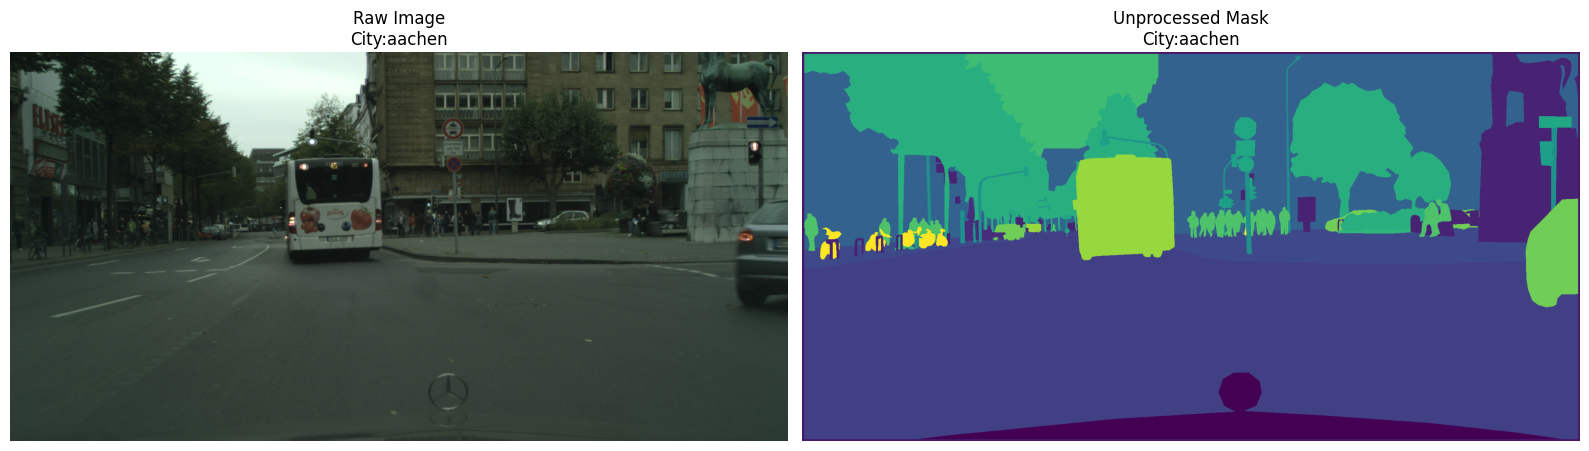

In [84]:
# 1. Select one random row from the DataFrame ~ sample specifying the number of samples n and seed
# ...iloc ~ global index/position in the table
# ...against loc which factors in the relative index
sample = dataset_annotations.sample(n=1, random_state=32).iloc[0]
_raw_img_path = sample['raw_image_path']
_mask = sample['mask_path']
_location = sample ['city']

# 2. & 3. Download the files using hf_hub_download
# Note: repo_id and repo_type are already defined in previous cells
image = hf_hub_download(repo_id=repo_id, repo_type=repo_type, filename=_raw_img_path)
mask = hf_hub_download(repo_id = repo_id, repo_type=repo_type, filename=_mask)

# 4. Load images using PIL
raw_img, raw_mask = Image.open(image), Image.open(mask)


# 5. & 6. Create side-by-side visualization
figure, axis = PLT.subplots(1,2,figsize=(16,10))

axis[0].imshow(raw_img)
axis[0].set_title(f"Raw Image\nCity:{_location}")
axis[0].set_axis_off()
axis[1].imshow(raw_mask)
axis[1].set_title(f"Unprocessed Mask\nCity:{_location}")
axis[1].set_axis_off()

PLT.tight_layout()


# Task
Analyze the city distribution in the `dataset_annotations` DataFrame and visualize it using a bar chart. First, aggregate the data to count the number of images per city. Create a mapping to categorize each of the 18 cities by country (Germany, France, or Switzerland). Use this mapping to assign specific colors to the bars, ensuring all cities from the same country share a consistent color while highlighting the international distribution. Finally, format the chart for readability by sorting the cities by frequency and adjusting the X-axis labels (e.g., rotation) to ensure all 18 city names are clearly visible.

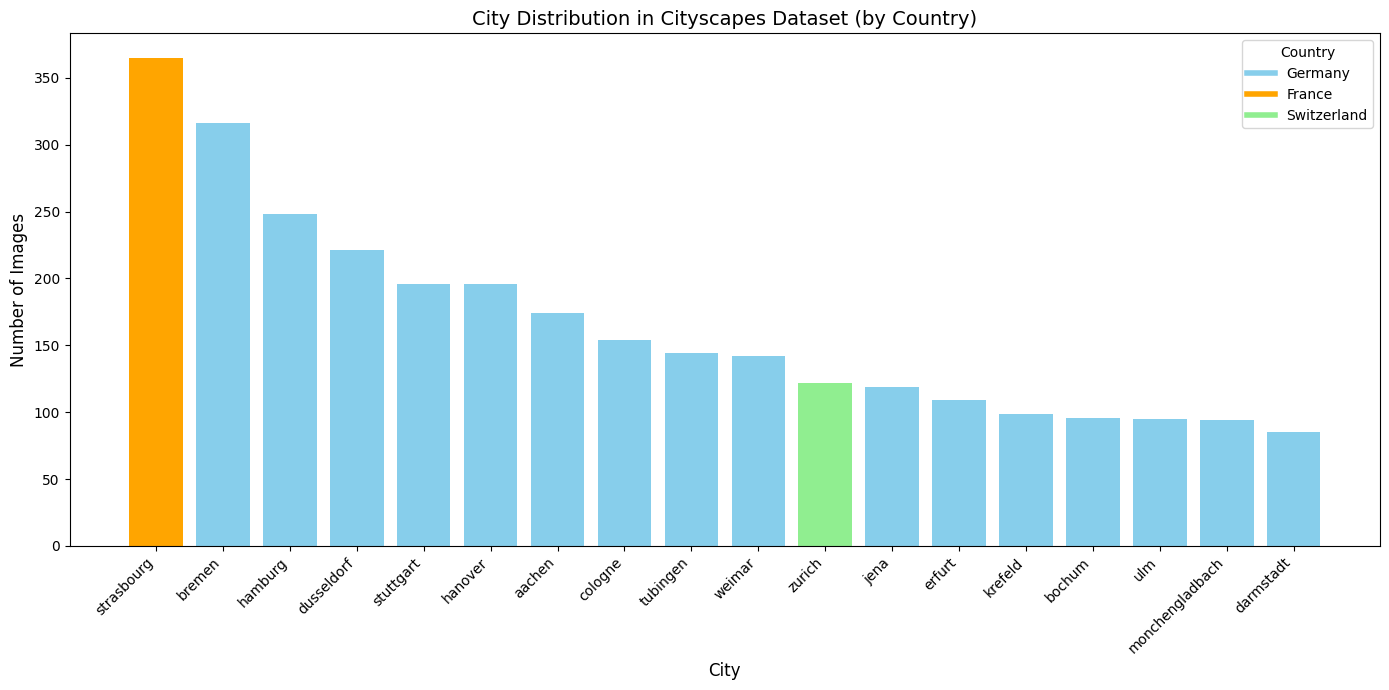

In [146]:
# 1 & 2. Calculate counts and convert to DataFrame
city_counts_df = dataset_annotations['city'].value_counts().reset_index()

# 2. Map dictionary to a new 'country' column
city_counts_df['country'] = city_counts_df['city'].map(country_map)


# 3. Define color mapping for countries
colors = {'Germany': 'skyblue', 'France': 'orange', 'Switzerland': 'lightgreen'}

# 4. Create the plot
PLT.figure(figsize=(14, 7))
bars = PLT.bar(city_counts_df['city'], city_counts_df['count'],
               color=[colors[c] for c in city_counts_df['country']])

# 5. Add labels and title
PLT.xlabel('City', fontsize=12)
PLT.ylabel('Number of Images', fontsize=12)
PLT.title('City Distribution in Cityscapes Dataset (by Country)', fontsize=14)
PLT.xticks(rotation=45, ha='right')

# 6. Create a legend manually
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='skyblue', lw=4, label='Germany'),
                   Line2D([0], [0], color='orange', lw=4, label='France'),
                   Line2D([0], [0], color='lightgreen', lw=4, label='Switzerland')]
PLT.legend(handles=legend_elements, title="Country")

PLT.tight_layout()
PLT.show()


# Conclusions

**Out of the 18 cities listed, 16 are located in Germany**, while only two are from other countries:


1.   Germany (16 cities): Bremen, Hamburg, Dusseldorf, Stuttgart, Hanover, Aachen, Cologne, Tubingen, Weimar, Jena, Erfurt, Krefeld, Bochum, Ulm, Monchengladbach, and Darmstadt;
2.   France (1 city): Strasbourg;
3.   Switzerland (1 city): Zurich;

In other words, base on the information the data card displays the current dataset is highly revolving around the central european zone which might make the model incapacitated to a certain degree if ever faced with images coming from other areas of the world (e.g., Romanian country side is entirely different from what German country side looks like).


The previous point is enforced by the distribution above although one could be reasonably led to believe that the data acquisition phase was geared towards diminishing city related unbalances by insisting on one single french zone (which might or might not be representative for the entire country) which should be enough to compensate for the left-vast majority consituted from over 16 german cities. However, it would be interesting to categorize/create accuracy buckets based on the zones to see if the model is able to consistently mantain its performance stable across different states.